## Preprocessing and visualizing notebook

### Initialize paths

In [3]:
from pathlib import Path
import ants

# Subject ID
subid = "0001"

# Base directories
udel_dir = Path("/home/oana/UDel/UDELData")
fs_dir = udel_dir / "fsruns" / subid
mre_base = udel_dir / "U01_UDEL_0001_01_v3" / "U01_UDEL_0001_01_MRE_AP_50Hz"
reg_dir = udel_dir / "U01_UDEL_0001_01_v3" / "U01_UDEL_0001_01_register_to_MRE"

out_dir = Path("/home/oana/MRE_analysis") / subid
out_dir.mkdir(parents=True, exist_ok=True)


# ANTs transform (MRE -> anatomical)
transform_path = reg_dir / "U01_UDEL_0001_01_MREreg_RigidTransform.mat"

# T1 reference (FreeSurfer)
t1_anat = fs_dir / "mri" / "orig.mgz"

# MRE volumes
mre_files = {
    "anat": mre_base / "U01_UDEL_0001_01_MRE_AP_50Hz_anat.nii.gz",
    "stiffness": mre_base / "U01_UDEL_0001_01_MRE_AP_50Hz_props_shear_stiff.nii.gz",
    "real": mre_base / "U01_UDEL_0001_01_MRE_AP_50Hz_props_shear_real.nii.gz",
    "imag": mre_base / "U01_UDEL_0001_01_MRE_AP_50Hz_props_shear_imag.nii.gz",
}



### 1. Invert the _RigidTransform.mat 

In [6]:
# Invert the transform
tx = ants.read_transform(str(transform_path))
tx_inv = tx.invert()

inv_path = out_dir / "MREreg_RigidTransform_INV.mat"
ants.write_transform(tx_inv, str(inv_path))

print("Saved inverted transform to:")
print(inv_path)


Saved inverted transform to:
/home/oana/MRE_analysis/0001/MREreg_RigidTransform_INV.mat


### 2. Apply the transform to MRE maps

In [3]:

ref_img = ants.image_read(str(t1_anat))
warped_files = {}

for name, mre_path in mre_files.items():
    print(f"\nProcessing: {name}")

    moving_img = ants.image_read(str(mre_path))

    out_path = out_dir / f"MRE_{name}_in_T1_space.nii.gz"

    warped = ants.apply_transforms(
        fixed=ref_img,
        moving=moving_img,
        transformlist=[str(inv_path)],
        interpolator="linear"
    )

    ants.image_write(warped, str(out_path))
    warped_files[name] = out_path
    print("Saved:", out_path)


Processing: anat
Saved: /home/oana/MRE_analysis/0001/MRE_anat_in_T1_space.nii.gz

Processing: stiffness
Saved: /home/oana/MRE_analysis/0001/MRE_stiffness_in_T1_space.nii.gz

Processing: real
Saved: /home/oana/MRE_analysis/0001/MRE_real_in_T1_space.nii.gz

Processing: imag
Saved: /home/oana/MRE_analysis/0001/MRE_imag_in_T1_space.nii.gz


### 3. Refine or validate the registration above with bbregister

source $FREESURFER_HOME/SetUpFreeSurfer.sh

export SUBJECTS_DIR=~/UDel/UDELData/fsruns

bbregister --s 0001 --mov /home/oana/MRE_analysis/0001/MRE_anat_in_T1_space.nii.gz --int $SUBJECTS_DIR/0001/mri/T1.mgz --t2 --reg mre50_anat_to_0001.dat --o MRE_anat_bbreg.nii.gz


### 4. Visualize

In [ ]:
from pathlib import Path
import sys
from cortech import Cortex
import nibabel as nib
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

subject = fs_dir
cortex = Cortex.from_freesurfer_subject_dir(subject, pial="pial.T1", registration="sphere.reg")

# smooth white/pial surfaces
for hemi in [cortex.lh, cortex.rh]:
    hemi.white.smooth_taubin(n_iter=5, inplace=True)
    hemi.pial.smooth_taubin(n_iter=5, inplace=True)

# estimate central surface
mid_layers = {
    "lh": cortex.lh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True),
    "rh": cortex.rh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True)
}


# interpolate all MRE data
surface_data = {}

warped_files = {
    "anat": out_dir / "MRE_anat_in_T1_space.nii.gz",
    "stiffness": out_dir / "MRE_stiffness_in_T1_space.nii.gz",
    "real": out_dir / "MRE_real_in_T1_space.nii.gz",
    "imag": out_dir / "MRE_imag_in_T1_space.nii.gz",
}

for name, vol_path in warped_files.items():
    img = nib.load(str(vol_path))
    data = img.get_fdata()
    affine = img.affine

    surface_data[name] = {
        hemi: mid_layers[hemi].interpolate_to_nodes(data, affine)
        for hemi in ["lh", "rh"]
    }

# Visualize MRE stiffness on the cortical surface
plotter = FsPlotter(subject=subject, surface="inflated")
plotter.add_curvature()
plotter.add_standard_morphological_data()
plotter.add_annotation("aparc")

for name, hemi_data in surface_data.items():
    plotter.add_overlay({"lh": hemi_data["lh"], "rh": hemi_data["rh"]}, name=f"MRE_{name}")

iplotter = InteractivePlotter(plotter)
widget = iplotter.get_widget()
widget


Widget(value='<iframe src="http://localhost:33369/index.html?ui=P_0x7f147330a510_1&reconnect=auto" class="pyvi…

In [ ]:
from pathlib import Path
import sys
from cortech import Cortex
import nibabel as nib
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

subject = fs_dir
cortex = Cortex.from_freesurfer_subject_dir(subject, pial="pial.T1", registration="sphere.reg")

# smooth white/pial surfaces
for hemi in [cortex.lh, cortex.rh]:
    hemi.white.smooth_taubin(n_iter=5, inplace=True)
    hemi.pial.smooth_taubin(n_iter=5, inplace=True)

# estimate central surface
mid_layers = {
    "lh": cortex.lh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True),
    "rh": cortex.rh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True)
}


# load MRE stiffness ("/home/oana/MRE_analysis/MRE_stiffness_in_T1_space.nii.gz")
# MRE anat to T1 space
stiff_img = nib.load("/home/oana/MRE_analysis/MRE_anat_in_T1_space.nii.gz")

interpolated_stiff = {}
for hemi in mid_layers.keys():
    interpolated_stiff[hemi] = mid_layers[hemi].interpolate_to_nodes(stiff_img.get_fdata(), stiff_img.affine)

# Visualize MRE stiffness on the cortical surface
sub_plotter = FsPlotter(subject=subject, surface='inflated')
sub_plotter.add_curvature()
sub_plotter.add_standard_morphological_data()
sub_plotter.add_annotation('aparc')
# Add MRE stiffness overlay
data_dict = {
    "lh": interpolated_stiff["lh"],
    "rh": interpolated_stiff["rh"]
}
sub_plotter.add_overlay(data_dict, name="MRE_stiffness")

iplotter = InteractivePlotter(sub_plotter)
widget = iplotter.get_widget()
widget

Widget(value='<iframe src="http://localhost:42417/index.html?ui=P_0x7f3ab3a9cf50_1&reconnect=auto" class="pyvi…

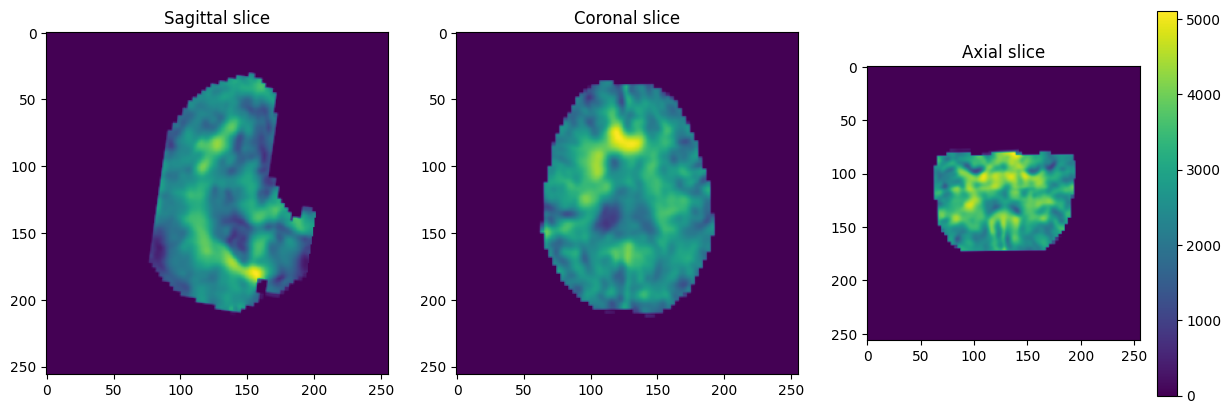

In [6]:
import matplotlib.pyplot as plt
import numpy as np

data = stiff_img.get_fdata()

# middle slices
fig, axes = plt.subplots(1,3, figsize=(15,5))
axes[0].imshow(np.rot90(data[data.shape[0]//2,:,:]), cmap='viridis')
axes[0].set_title('Sagittal slice')
axes[1].imshow(np.rot90(data[:,data.shape[1]//2,:]), cmap='viridis')
axes[1].set_title('Coronal slice')
axes[2].imshow(np.rot90(data[:,:,data.shape[2]//2]), cmap='viridis')
axes[2].set_title('Axial slice')
plt.colorbar(axes[2].imshow(np.rot90(data[:,:,data.shape[2]//2]), cmap='viridis'))
plt.show()


In [3]:
from pathlib import Path
import nibabel as nib

out_dir = Path("/home/oana/MRE_analysis/freesurfer_overlays")
out_dir.mkdir(parents=True, exist_ok=True)

for hemi in ["lh", "rh"]:
    overlay = nib.freesurfer.mghformat.MGHImage(
        interpolated_stiff[hemi].astype("float32"),
        stiff_img.affine
    )
    out_file = out_dir / f"{hemi}.mid.layer.MREstiffness.mgh"
    nib.save(overlay, out_file)
    print("Saved:", out_file)


Saved: /home/oana/MRE_analysis/freesurfer_overlays/lh.mid.layer.MREstiffness.mgh
Saved: /home/oana/MRE_analysis/freesurfer_overlays/rh.mid.layer.MREstiffness.mgh


In [10]:
!freeview \
  -v /home/oana/UDel/UDELData/fsruns/0001/mri/norm.mgz \
  -f /home/oana/UDel/UDELData/fsruns/0001/surf/lh.inflated:/home/oana/MRE_analysis/freesurfer_overlays/lh.mid.layer.MREstiffness.mgh \
  -f /home/oana/UDel/UDELData/fsruns/0001/surf/rh.inflated:/home/oana/MRE_analysis/freesurfer_overlays/rh.mid.layer.MREstiffness.mgh


In [ ]:
!freeview \
  -v /home/oana/UDel/UDELData/fsruns/0001/mri/norm.mgz \
  -f /home/oana/UDel/UDELData/fsruns/0001/surf/lh.white \
  -f /home/oana/UDel/UDELData/fsruns/0001/surf/lh.pial.T1 \
  -f /home/oana/UDel/UDELData/fsruns/0001/surf/lh.inflated:/home/oana/MRE_analysis/freesurfer_overlays/lh.mid.layer.MREstiffness.mgh \
  -f /home/oana/UDel/UDELData/fsruns/0001/surf/rh.white \
  -f /home/oana/UDel/UDELData/fsruns/0001/surf/rh.pial.T1 \
  -f /home/oana/UDel/UDELData/fsruns/0001/surf/rh.inflated:/home/oana/MRE_analysis/freesurfer_overlays/rh.mid.layer.MREstiffness.mgh
